# Arabic Word Recognition
### Single-class YOLO (find characters) + CNN (classify characters)
#### Dataset: my own handwritten words labelled in Label Studio

## 1. Install & Import

In [2]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow Pillow tqdm seaborn

In [3]:
import os, shutil, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Dropout,
    BatchNormalization, Flatten, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.21.0
GPU available: False


In [6]:
from pathlib import Path
import cv2
import numpy as np

MY_DATASET  = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset")
OUTPUT_DIR  = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_chars")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load class names from your Label Studio export
classes_file = MY_DATASET / "classes.txt"
classes = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
print(f"Classes: {classes}")

count = 0
for split in ['train', 'val']:
    img_dir = MY_DATASET / split / 'images'
    lbl_dir = MY_DATASET / split / 'labels'

    for img_path in sorted(img_dir.glob('*.*')):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        H, W = img.shape[:2]

        for line in lbl_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            class_id = int(parts[0])
            x_c, y_c, bw, bh = map(float, parts[1:5])

            # Convert YOLO normalized coords to pixel coords
            x1 = int((x_c - bw/2) * W)
            y1 = int((y_c - bh/2) * H)
            x2 = int((x_c + bw/2) * W)
            y2 = int((y_c + bh/2) * H)

            # Clamp to image bounds
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # Save crop into a subfolder named after the class
            label = classes[class_id]
            out_dir = OUTPUT_DIR / label
            out_dir.mkdir(exist_ok=True)
            out_path = out_dir / f"{img_path.stem}_{count:04d}.png"
            cv2.imwrite(str(out_path), crop)
            count += 1

print(f"\nExtracted {count} character crops to {OUTPUT_DIR}")
print("Subfolders created:")
for d in sorted(OUTPUT_DIR.iterdir()):
    imgs = list(d.glob('*.png'))
    print(f"  {d.name}: {len(imgs)} images")

Classes: ['ain_begin', 'ain_end', 'ain_middle', 'ain_regular', 'alif_end', 'alif_hamza', 'alif_regular', 'beh_begin', 'beh_end', 'beh_middle', 'beh_regular', 'dad_begin', 'dad_end', 'dad_middle', 'dad_regular', 'dal_end', 'dal_regular', 'feh_begin', 'feh_end', 'feh_middle', 'feh_regular', 'ghain_begin', 'ghain_end', 'ghain_middle', 'ghain_regular', 'hah_begin', 'hah_end', 'hah_middle', 'hah_regular', 'hamza', 'heh_begin', 'heh_end', 'heh_middle', 'heh_regular', 'jeem_begin', 'jeem_end', 'jeem_middle', 'jeem_regular', 'kaf_begin', 'kaf_end', 'kaf_middle', 'kaf_regular', 'khah_begin', 'khah_end', 'khah_middle', 'khah_regular', 'lam_alif', 'lam_begin', 'lam_end', 'lam_middle', 'lam_regular', 'meem_begin', 'meem_end', 'meem_middle', 'meem_regular', 'noon_begin', 'noon_end', 'noon_middle', 'noon_regular', 'qaf_begin', 'qaf_end', 'qaf_middle', 'qaf_regular', 'raa_end', 'raa_regular', 'sad_begin', 'sad_end', 'sad_middle', 'sad_regular', 'seen_begin', 'seen_end', 'seen_middle', 'seen_regular',

## 2. Paths

In [7]:
ROOT       = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN")
AHAWP_DIR  = ROOT / "isolated_alphabets_per_alphabet"
MY_DATASET = ROOT / "my_dataset"
MY_CHARS   = ROOT / "my_chars"
IMG_SIZE   = 64

for p in [ROOT, AHAWP_DIR, MY_DATASET]:
    print(f"{'OK' if p.exists() else 'MISSING'}: {p}")

OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_alphabets_per_alphabet
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset


## 3. CNN Training — Character Classifier
Trained on AHAWP isolated characters. Uses grayscale 64×64 input.

In [9]:
FORM_MAP = {
    'begin':   'beginning',
    'middle':  'middle',
    'end':     'end',
    'regular': 'isolated',
    'hamza':   'hamza',
    'alif':    'alif',
}

def load_isolated_dataset(alphabets_dir, img_size=IMG_SIZE):
    """Loads from AHAWP-style folders: ain_begin, beh_middle etc."""
    images, labels = [], []
    for subfolder in sorted(alphabets_dir.iterdir()):
        if not subfolder.is_dir():
            continue
        parts = subfolder.name.rsplit('_', 1)
        if len(parts) != 2:
            continue
        letter, form_raw = parts
        form = FORM_MAP.get(form_raw)
        if form is None:
            continue
        label = f"{letter}_{form}"
        for img_path in sorted(subfolder.glob("*.png")):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)
    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    y = np.array(labels)
    print(f"Loaded {len(X)} images across {len(set(labels))} classes")
    return X, y


def load_my_chars(my_chars_dir, img_size=IMG_SIZE):
    """Loads from my_chars folders: ain_beginning, beh_middle etc. (Label Studio names)."""
    images, labels = [], []
    for subfolder in sorted(my_chars_dir.iterdir()):
        if not subfolder.is_dir():
            continue
        label = subfolder.name  # already in correct format e.g. beh_beginning
        for img_path in sorted(subfolder.glob("*.png")):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)
    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    y = np.array(labels)
    print(f"Loaded {len(X)} images across {len(set(labels))} classes")
    return X, y


# Load both datasets and combine
X_ahawp, y_ahawp = load_isolated_dataset(AHAWP_DIR)
X_mine,  y_mine  = load_my_chars(MY_CHARS)

X_all = np.concatenate([X_ahawp, X_mine], axis=0)
y_all = np.concatenate([y_ahawp, y_mine], axis=0)
print(f"\nCombined: {len(X_all)} images")

le = LabelEncoder()
y_encoded = le.fit_transform(y_all)
NUM_CLASSES   = len(le.classes_)
ARABIC_LABELS = list(le.classes_)

np.save("label_classes.npy", le.classes_)
print(f"Classes: {NUM_CLASSES}")
print(ARABIC_LABELS)

Loaded 53199 images across 65 classes
Loaded 223 images across 1 classes

Combined: 53422 images
Classes: 66
[np.str_('ain_begin'), np.str_('ain_beginning'), np.str_('ain_end'), np.str_('ain_isolated'), np.str_('ain_middle'), np.str_('alif_end'), np.str_('alif_hamza'), np.str_('alif_isolated'), np.str_('beh_beginning'), np.str_('beh_end'), np.str_('beh_isolated'), np.str_('beh_middle'), np.str_('dal_end'), np.str_('dal_isolated'), np.str_('feh_beginning'), np.str_('feh_end'), np.str_('feh_isolated'), np.str_('feh_middle'), np.str_('heh_beginning'), np.str_('heh_end'), np.str_('heh_isolated'), np.str_('heh_middle'), np.str_('jeem_beginning'), np.str_('jeem_end'), np.str_('jeem_isolated'), np.str_('jeem_middle'), np.str_('kaf_beginning'), np.str_('kaf_end'), np.str_('kaf_isolated'), np.str_('kaf_middle'), np.str_('lam_alif'), np.str_('lam_beginning'), np.str_('lam_end'), np.str_('lam_isolated'), np.str_('lam_middle'), np.str_('meem_beginning'), np.str_('meem_end'), np.str_('meem_isolated

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.25, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (40066, 64, 64, 1)  Val: (6678, 64, 64, 1)  Test: (6678, 64, 64, 1)


In [11]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, 3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.25),

        Conv2D(64, 3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.25),

        Conv2D(128, 3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.25),

        Conv2D(256, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ], name='ArabicCharCNN')
    return model


model = build_cnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "ArabicCharCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,832,418 (10.80 MB)

 Trainable params: 2,829,986 (10.80 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [12]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_arabic_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

model.save('arabic_cnn_final.keras')
print("Saved: arabic_cnn_final.keras")

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.1067 - loss: 3.9660
Epoch 1: val_accuracy improved from None to 0.09389, saving model to best_arabic_cnn.keras

Epoch 1: finished saving model to best_arabic_cnn.keras
627/627 ━━━━━━━━━━━━━━━━━━━━ 315s 494ms/step - accuracy: 0.2297 - loss: 3.0754 - val_accuracy: 0.0939 - val_loss: 10.4278 - learning_rate: 0.0010
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.5080 - loss: 1.6445
Epoch 2: val_accuracy did not improve from 0.09389
627/627 ━━━━━━━━━━━━━━━━━━━━ 347s 553ms/step - accuracy: 0.5814 - loss: 1.3871 - val_accuracy: 0.0572 - val_loss: 12.6920 - learning_rate: 0.0010
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.6950 - loss: 0.9990
Epoch 3: val_accuracy did not improve from 0.09389
627/627 ━━━━━━━━━━━━━━━━━━━━ 361s 575ms/step - accuracy: 0.7000 - loss: 0.9934 - val_accuracy: 0.0123 - val_loss: 29.9769 - learning_rate: 0.0010
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms

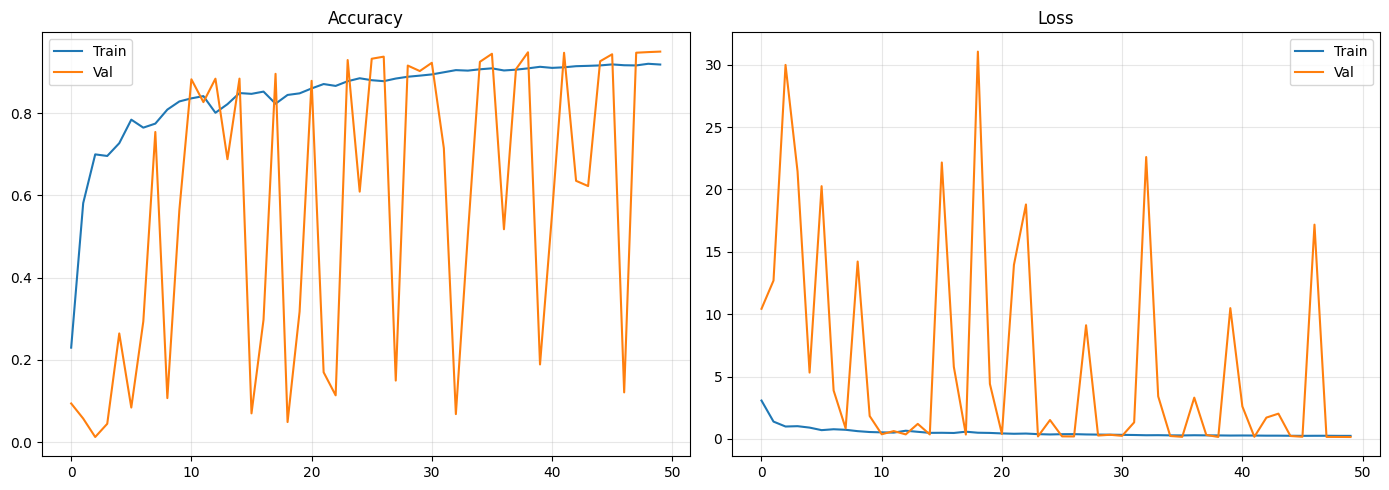

Test Accuracy: 0.9516 (95.16%)
209/209 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step
                precision    recall  f1-score   support

     ain_begin       1.00      1.00      1.00        28
 ain_beginning       0.99      0.95      0.97       102
       ain_end       0.97      0.99      0.98       103
  ain_isolated       0.99      0.98      0.99       103
    ain_middle       0.93      0.89      0.91       102
      alif_end       1.00      0.97      0.99       102
    alif_hamza       0.98      0.98      0.98       102
 alif_isolated       0.95      0.99      0.97       102
 beh_beginning       1.00      0.92      0.96       103
       beh_end       0.93      1.00      0.96       102
  beh_isolated       0.97      1.00      0.99       102
    beh_middle       0.97      0.86      0.91       103
       dal_end       0.98      0.82      0.89       103
  dal_isolated       0.93      0.91      0.92       102
 feh_beginning       0.92      0.86      0.89       101
       feh_end       0.89     

In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

y_pred = np.argmax(model.predict(X_test), axis=1)
present = sorted(np.unique(np.concatenate([y_test, y_pred])))
present_names = [ARABIC_LABELS[i] for i in present]
print(classification_report(y_test, y_pred, labels=present, target_names=present_names))

## 4. YOLO Training — Single-Class Character Detector
YOLO only learns to **locate** characters (1 class). CNN handles classification.
This works much better with small datasets.

In [14]:
# Convert all Label Studio labels to single class (class_id = 0)
def convert_to_single_class(dataset_dir):
    for split in ['train', 'val']:
        labels_dir = dataset_dir / split / 'labels'
        if not labels_dir.exists():
            print(f"  Skipping {split} — not found")
            continue
        count = 0
        for txt_file in labels_dir.glob('*.txt'):
            lines = txt_file.read_text().splitlines()
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
            txt_file.write_text('\n'.join(new_lines) + '\n')
            count += 1
        print(f"  Converted {count} label files in {split}/")

print("Converting labels to single-class...")
convert_to_single_class(MY_DATASET)

# Verify dataset
train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train images: {len(train_imgs)}")
print(f"Val images  : {len(val_imgs)}")

Converting labels to single-class...
  Converted 60 label files in train/
  Converted 13 label files in val/
Train images: 60
Val images  : 13


In [15]:
# Write single-class data.yaml
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names:\n")
    f.write("  - character\n")

print(open(yaml_path).read())

path: F:/bach2/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 1
names:
  - character



In [16]:
# Train YOLO
n_train = len(train_imgs)

yolo_model = YOLO('yolov8s.pt')
yolo_results = yolo_model.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=4,
    patience=30,
    device='cpu',
    project=str(ROOT / 'my_yolo'),
    name='char_detector',
    exist_ok=True,
    degrees=10.0,
    translate=0.15,
    scale=0.4,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.5 if n_train >= 50 else 0.0,
    mixup=0.1  if n_train >= 50 else 0.0,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
)

YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO done. Weights exist: {YOLO_WEIGHTS.exists()}")

New https://pypi.org/project/ultralytics/8.4.26 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0

## 5. Inference Pipeline

In [17]:
# Load models
YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'

cnn_model     = load_model('best_arabic_cnn.keras')
yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load('label_classes.npy', allow_pickle=True)

print(f"CNN loaded")
print(f"YOLO loaded: {YOLO_WEIGHTS}")
print(f"Classes: {len(label_classes)}")

CNN loaded
YOLO loaded: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_yolo\char_detector\weights\best.pt
Classes: 66


In [18]:
def preprocess_for_cnn(crop_bgr, img_size=IMG_SIZE):
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    roi = thresh[y:y+h, x:x+w]
    side = int(max(h, w) * 1.3)
    canvas = np.zeros((side, side), dtype='uint8')
    ox, oy = (side - w) // 2, (side - h) // 2
    canvas[oy:oy+h, ox:ox+w] = roi
    resized = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    return normalized[..., np.newaxis]


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W = img.shape[:2]
    annotated = img.copy()

    # YOLO — find character boxes (single class)
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes = results.boxes

    if len(boxes) == 0:
        print("No characters detected.")
        return [], [], annotated

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(W, x2), min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        # CNN — classify the crop
        proc = preprocess_for_cnn(crop)
        if proc is None:
            continue
        preds = cnn_model.predict(np.expand_dims(proc, axis=0), verbose=0)[0]
        cnn_idx  = np.argmax(preds)
        cnn_conf = float(preds[cnn_idx])
        full_label = str(label_classes[cnn_idx])          # e.g. beh_beginning
        base_label = full_label.rsplit('_', 1)[0]         # e.g. beh

        detections.append((x1, y1, x2, y2, full_label, base_label, cnn_conf))

    # Sort right-to-left
    detections.sort(key=lambda d: -d[0])

    full_labels, base_labels = [], []
    for (x1, y1, x2, y2, full, base, conf) in detections:
        full_labels.append(full)
        base_labels.append(base)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(annotated, f"{base} {conf:.0%}",
                    (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 0), 1)

    return base_labels, full_labels, annotated


print("Inference pipeline ready.")

Inference pipeline ready.


Letters (simple): ain ain ain
Letters (with form): ain_begin ain_begin ain_begin


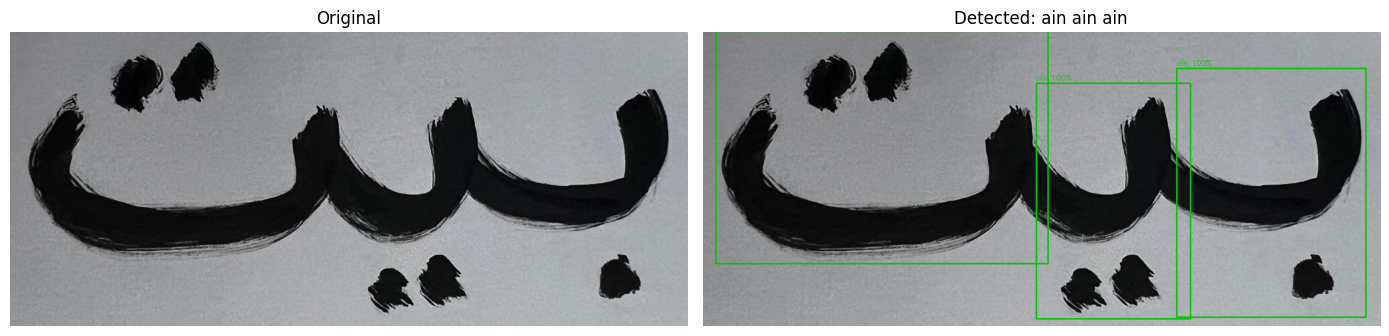

In [19]:
# ── Test on a single image ────────────────────────────────────
# Change this to any word image you want to test
TEST_IMAGE = str(ROOT / 'word_test.png')

base_chars, full_chars, annotated_img = recognize_word(
    TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4
)

print(f"Letters (simple): {' '.join(base_chars)}")
print(f"Letters (with form): {' '.join(full_chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(base_chars)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Testing on 13 val images...

ce0882a8-WhatsApp_Image_2026-03-23_at_2.21.24_AM_8.jpeg: ain ain ain


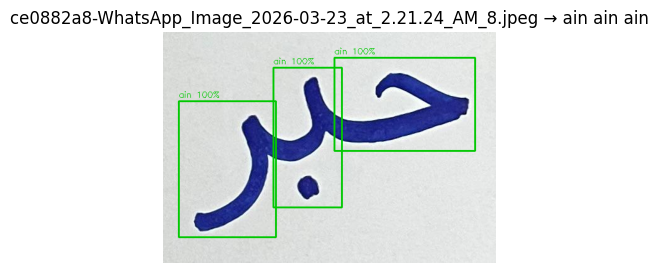

d272ef07-WhatsApp_Image_2026-03-23_at_2.21.26_AM_25.jpeg: ain ain ain


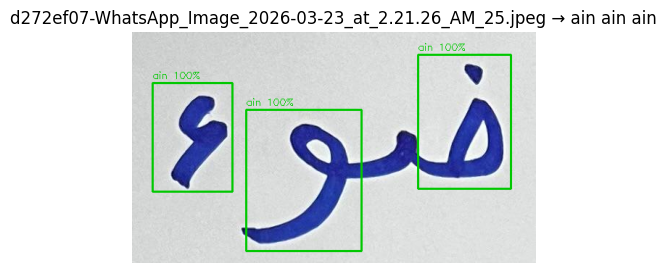

da1fee74-WhatsApp_Image_2026-03-23_at_2.21.26_AM_18.jpeg: ain ain ain


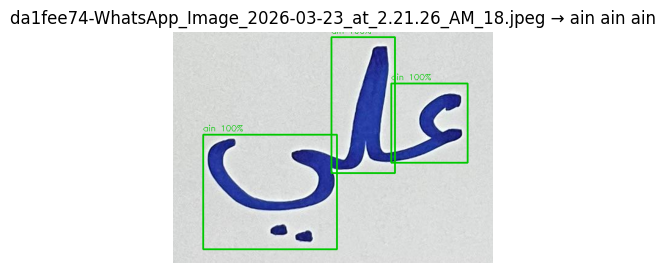

dd921431-WhatsApp_Image_2026-03-23_at_2.21.26_AM_20.jpeg: ain ain ain ain ain


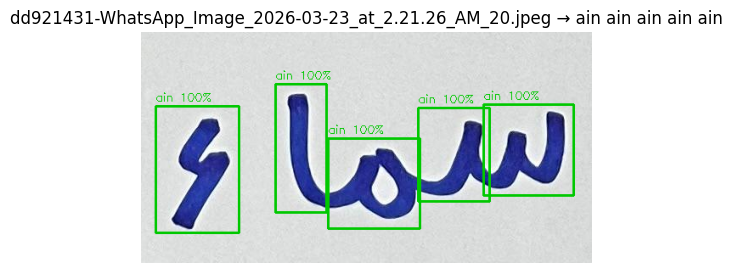

e05f66fa-WhatsApp_Image_2026-03-23_at_2.21.26_AM_9.jpeg: ain ain ain


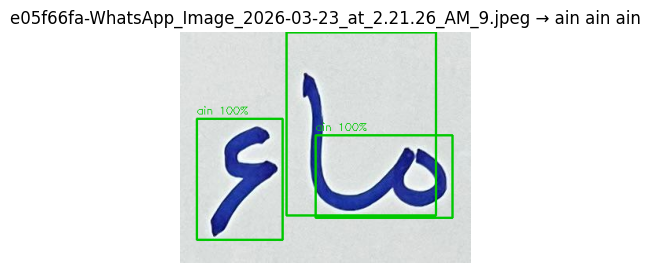

e47bdbbb-WhatsApp_Image_2026-03-23_at_2.21.26_AM_47.jpeg: ain ain


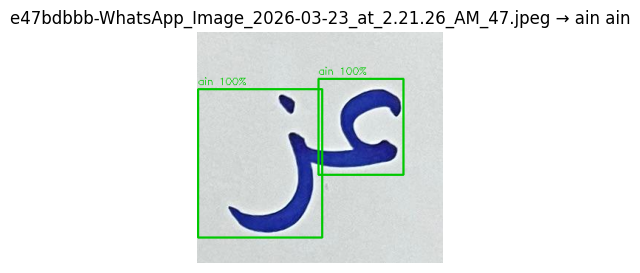

e8f36542-WhatsApp_Image_2026-03-23_at_2.21.26_AM_21.jpeg: ain ain ain


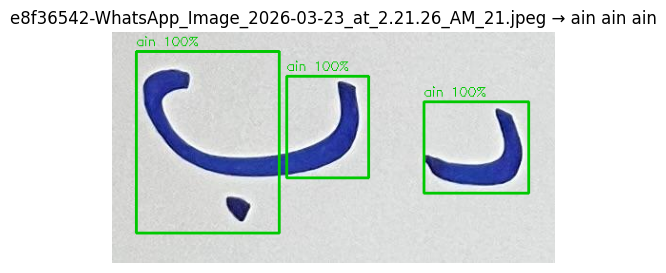

ee3eef31-WhatsApp_Image_2026-03-23_at_2.21.26_AM_40.jpeg: ain ain ain


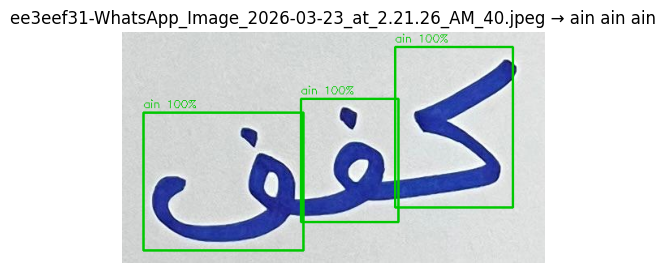

ef978434-WhatsApp_Image_2026-03-23_at_2.21.24_AM_1.jpeg: ain ain ain


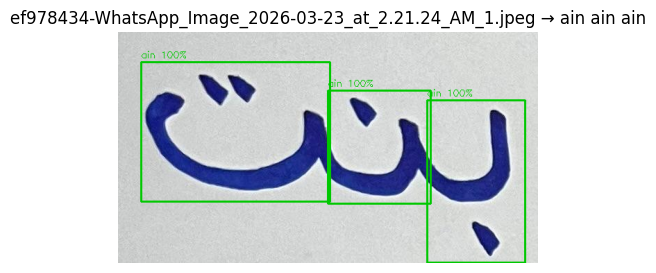

f1769f84-WhatsApp_Image_2026-03-23_at_2.21.26_AM_11.jpeg: ain ain ain


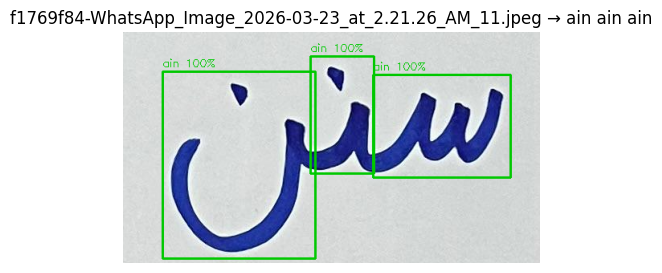

In [20]:
# ── Test on all val images ────────────────────────────────────
val_images = list((MY_DATASET / 'val' / 'images').glob('*.*'))
print(f"Testing on {len(val_images)} val images...\n")

for img_path in val_images[:10]:
    try:
        base_chars, _, annotated = recognize_word(str(img_path))
        print(f"{img_path.name}: {' '.join(base_chars)}")
        plt.figure(figsize=(8, 3))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"{img_path.name} → {' '.join(base_chars)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error on {img_path.name}: {e}")